In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pickle
import time
import seaborn as sns
from scipy.optimize import fmin, minimize, LinearConstraint, Bounds
from efficient_fpt.multi_stage_cy import compute_loss_parallel, print_num_threads
import pymc 

data = pickle.load(open("addm_data_20251015-163921.pkl", "rb"))


In [ ]:
DATA_TYPE = np.float64

a = data["a"] # decision threshold  
b = data["b"] # slope of collapsing boundary 
x0 = data["x0"] # initial starting point? 
eta_true = data["eta"] # scaling factor against the option not being fixated 
kappa_true = data["kappa"] # parametrizes whole drift..? 
r1_data = data["r1_data"] # reward value of option 1 
r2_data = data["r2_data"] # reward value of option 2 
flag_data = data["flag_data"].astype(np.int32) # what is this 

sigma = data["sigma"] # diffusion noise 
T = data["T"] # max time 

mu1_true_data = kappa_true * (r1_data - eta_true * r2_data)
mu2_true_data = kappa_true * (eta_true * r1_data - r2_data)

mu_true_data = data["mu_array_padded_data"].astype(DATA_TYPE)
sacc_data = data["sacc_array_padded_data"].astype(DATA_TYPE) # what is the sacc_data? 
length_data = data["d_data"].astype(np.int32)
rt_data = data["decision_data"][:, 0].astype(DATA_TYPE)
choice_data = data["decision_data"][:, 1].astype(np.int32)

num_data, max_d = mu_true_data.shape
print(num_data, max_d)

50000 12


In [12]:
print(sacc_data.shape)

(50000, 12)


In [3]:
num_iter = 5
start_time = time.time()
for _ in range(num_iter):
    loss = compute_loss_parallel(
        mu1_true_data,
        mu2_true_data,
        rt_data,
        choice_data,
        flag_data,
        sacc_data,
        length_data,
        max_d,
        sigma,
        a,
        b,
        x0,
        num_threads=32,
    )
    print(loss)
end_time = time.time()
print(f"Likelihood evaluation time: {(end_time - start_time) / num_iter:.3f} s")

1.4853344770222021
1.4853344770222021
1.4853344770222023
1.4853344770222021
1.4853344770222023
Likelihood evaluation time: 1.192 s


50000


(array([3.52768527e-04, 8.81921319e-04, 1.05830558e-03, 2.46937969e-03,
        2.46937969e-03, 4.76237512e-03, 5.29152791e-03, 5.46791217e-03,
        6.70260202e-03, 1.14649771e-02, 1.44635096e-02, 1.76384264e-02,
        1.79911949e-02, 2.01078061e-02, 2.89270192e-02, 2.76923294e-02,
        3.26310888e-02, 3.63351583e-02, 3.80990010e-02, 4.53307558e-02,
        5.43263532e-02, 6.04998025e-02, 6.22636451e-02, 6.80843258e-02,
        7.40813908e-02, 8.34297567e-02, 8.78393633e-02, 9.48947339e-02,
        1.09534628e-01, 1.21175989e-01, 1.29995202e-01, 1.39343568e-01,
        1.54159846e-01, 1.68799740e-01, 1.76913416e-01, 1.95962917e-01,
        2.06722357e-01, 2.31768923e-01, 2.35825761e-01, 2.56639104e-01,
        2.76041373e-01, 2.84860586e-01, 2.87859118e-01, 2.82567590e-01,
        2.50465654e-01, 1.67035898e-01, 7.72563075e-02, 1.21705142e-02,
        1.76384264e-04, 0.00000000e+00, 0.00000000e+00, 5.29152791e-04,
        2.06369589e-02, 7.02009370e-02, 1.25409211e-01, 1.672122

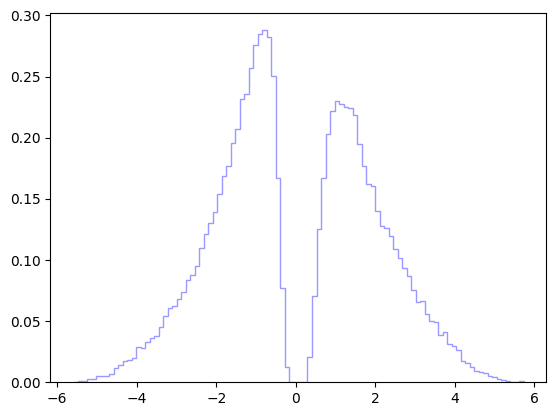

In [10]:
print(len(rt_data))
plt.hist(rt_data*choice_data, bins=100,
    histtype="step",
    color="blue",
    density=True,
    alpha=0.4,)

In [27]:
T = 2.1 / 0.3 
rng = np.random.default_rng() 
fixations = rng.gamma(6, 0.1, size=1000)
sacc_array = np.insert(np.cumsum(fixations), 0, 0)
sacc_array = sacc_array[sacc_array < T]
print(sacc_array.shape)

(14,)
